# 📊 Dataset Information

**Note:** The dataset for this project is **not included in this repository** to keep the repository lightweight.  

You can download the dataset from **Kaggle** using the link below:  

[Download The Sleep Doomscrolling Habits Dataset](https://www.kaggle.com/datasets/harpartapsingh13/sleep-and-doomscrolling-habits-dataset)  

Please make sure to place the downloaded CSV file in the same directory as this notebook before running any code.	

# Importing

## Import Library

In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

## Import CSV And convert to DataFrame

In [48]:
df = pd.read_csv('sleep_doomscrolling_habits.csv')

# Preprocessing

## Frist five row

In [49]:
pd.set_option('display.max_columns', None)
df.head()

,respondent_id,age,bedtime_screen_time_minutes,total_daily_screen_time_hours,doomscroll_sessions_per_night,avg_doomscroll_session_minutes,sleep_hours_per_night,sleep_latency_minutes,number_of_night_wakeups,caffeine_intake_mg_per_day,anxiety_score,stress_score,sleep_quality_score,daytime_fatigue_score,number_of_news_apps_used,phone_checks_per_night,exercise_minutes_per_day,days_since_last_digital_detox,weekly_sleep_debt_hours,gender,occupation_status,country_region,primary_device_used_at_night,bedtime_routine_type,uses_night_mode,keeps_phone_in_bedroom,consumes_negative_news_content,uses_sleep_tracking_app,doomscroller,sleep_quality_category
0,D30000,22,13.0,1.85,2,5.4,8.1,19.0,2,155.0,5,7,5.0,6,3,3,103.0,9.0,0.7,Male,Unemployed,Germany,Tablet,Meditation/Journaling,Yes,Yes,Yes,No,Yes,Good
1,D30001,18,90.0,3.61,3,29.6,7.0,31.0,3,82.0,5,6,3.0,9,2,3,28.0,24.0,7.5,Male,Student,India,Smartphone,Meditation/Journaling,No,Yes,Yes,No,Yes,Poor
2,D30002,37,51.0,5.15,3,15.5,7.1,24.0,2,49.0,2,2,5.0,8,0,3,11.0,15.0,2.9,Prefer not to say,Student,India,Laptop,Reading,No,Yes,No,Yes,Yes,Fair
3,D30003,27,53.0,3.74,0,51.4,8.4,35.0,0,42.0,6,6,5.0,4,1,0,61.0,13.0,0.0,Prefer not to say,NaN,United States,Smartphone,No Fixed Routine,No,Yes,Yes,No,No,Fair
4,D30004,17,67.0,6.09,2,32.2,7.2,19.0,1,76.0,5,7,5.0,7,3,3,23.0,19.0,5.4,Prefer not to say,Employed Part-time,United States,Smartphone,Watching Videos,No,No,No,No,No,Fair


## last Five row

In [50]:
df.tail()

,respondent_id,age,bedtime_screen_time_minutes,total_daily_screen_time_hours,doomscroll_sessions_per_night,avg_doomscroll_session_minutes,sleep_hours_per_night,sleep_latency_minutes,number_of_night_wakeups,caffeine_intake_mg_per_day,anxiety_score,stress_score,sleep_quality_score,daytime_fatigue_score,number_of_news_apps_used,phone_checks_per_night,exercise_minutes_per_day,days_since_last_digital_detox,weekly_sleep_debt_hours,gender,occupation_status,country_region,primary_device_used_at_night,bedtime_routine_type,uses_night_mode,keeps_phone_in_bedroom,consumes_negative_news_content,uses_sleep_tracking_app,doomscroller,sleep_quality_category
995,D30995,26,85.0,3.56,4,25.4,7.6,34.0,1,169.0,10,8,5.0,4,1,1,71.0,14.0,3.3,Female,Student,India,Tablet,Meditation/Journaling,No,Yes,Yes,Yes,Yes,Poor
996,D30996,23,3.0,1.10,1,10.7,7.5,31.0,1,34.0,5,8,5.0,7,0,2,57.0,14.0,6.7,Male,Student,United States,Smartphone,Scrolling Social Media,No,Yes,No,No,No,Fair
997,D30997,15,28.0,4.38,1,30.6,9.2,20.0,0,100.0,3,5,5.0,5,1,1,43.0,52.0,0.0,Female,Employed Full-time,United States,Smartphone,Scrolling Social Media,No,Yes,No,No,No,Good
998,D30998,22,23.0,1.84,0,27.9,6.9,41.0,2,45.0,3,5,5.0,5,2,2,44.0,101.0,6.8,Male,Student,India,Tablet,Watching Videos,No,Yes,Yes,Yes,No,Fair
999,D30999,23,35.0,1.66,2,16.2,7.5,27.0,2,63.0,8,6,5.0,9,1,3,78.0,20.0,0.0,Prefer not to say,Employed Full-time,India,Tablet,Scrolling Social Media,No,Yes,Yes,No,Yes,Fair


## Shape of our dataset

In [51]:
df.shape

(1000, 30)

## List out all columns

In [52]:
df.columns

Index(['respondent_id', 'age', 'bedtime_screen_time_minutes',
       'total_daily_screen_time_hours', 'doomscroll_sessions_per_night',
       'avg_doomscroll_session_minutes', 'sleep_hours_per_night',
       'sleep_latency_minutes', 'number_of_night_wakeups',
       'caffeine_intake_mg_per_day', 'anxiety_score', 'stress_score',
       'sleep_quality_score', 'daytime_fatigue_score',
       'number_of_news_apps_used', 'phone_checks_per_night',
       'exercise_minutes_per_day', 'days_since_last_digital_detox',
       'weekly_sleep_debt_hours', 'gender', 'occupation_status',
       'country_region', 'primary_device_used_at_night',
       'bedtime_routine_type', 'uses_night_mode', 'keeps_phone_in_bedroom',
       'consumes_negative_news_content', 'uses_sleep_tracking_app',
       'doomscroller', 'sleep_quality_category'],
      dtype='object')

## Datatype of each columns

In [53]:
df.dtypes

respondent_id                      object
age                                 int64
bedtime_screen_time_minutes       float64
total_daily_screen_time_hours     float64
doomscroll_sessions_per_night       int64
avg_doomscroll_session_minutes    float64
sleep_hours_per_night             float64
sleep_latency_minutes             float64
number_of_night_wakeups             int64
caffeine_intake_mg_per_day        float64
anxiety_score                       int64
stress_score                        int64
sleep_quality_score               float64
daytime_fatigue_score               int64
number_of_news_apps_used            int64
phone_checks_per_night              int64
exercise_minutes_per_day          float64
days_since_last_digital_detox     float64
weekly_sleep_debt_hours           float64
gender                             object
occupation_status                  object
country_region                     object
primary_device_used_at_night       object
bedtime_routine_type              

## Information of all Columns

In [54]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 30 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   respondent_id                   1000 non-null   object 
 1   age                             1000 non-null   int64  
 2   bedtime_screen_time_minutes     1000 non-null   float64
 3   total_daily_screen_time_hours   1000 non-null   float64
 4   doomscroll_sessions_per_night   1000 non-null   int64  
 5   avg_doomscroll_session_minutes  1000 non-null   float64
 6   sleep_hours_per_night           1000 non-null   float64
 7   sleep_latency_minutes           1000 non-null   float64
 8   number_of_night_wakeups         1000 non-null   int64  
 9   caffeine_intake_mg_per_day      950 non-null    float64
 10  anxiety_score                   1000 non-null   int64  
 11  stress_score                    1000 non-null   int64  
 12  sleep_quality_score             960

## Check Null Value

In [55]:
df.isnull().sum()

respondent_id                      0
age                                0
bedtime_screen_time_minutes        0
total_daily_screen_time_hours      0
doomscroll_sessions_per_night      0
avg_doomscroll_session_minutes     0
sleep_hours_per_night              0
sleep_latency_minutes              0
number_of_night_wakeups            0
caffeine_intake_mg_per_day        50
anxiety_score                      0
stress_score                       0
sleep_quality_score               40
daytime_fatigue_score              0
number_of_news_apps_used           0
phone_checks_per_night             0
exercise_minutes_per_day          50
days_since_last_digital_detox      0
weekly_sleep_debt_hours            0
gender                             0
occupation_status                 30
country_region                     0
primary_device_used_at_night      30
bedtime_routine_type              20
uses_night_mode                    0
keeps_phone_in_bedroom             0
consumes_negative_news_content     0
u

## Fill missing columns with median and mode

In [56]:
df["caffeine_intake_mg_per_day"] = df["caffeine_intake_mg_per_day"].fillna(
    df["caffeine_intake_mg_per_day"].median()
)

df["sleep_quality_score"] = df["sleep_quality_score"].fillna(
    df["sleep_quality_score"].median()
)

df["exercise_minutes_per_day"] = df["exercise_minutes_per_day"].fillna(
    df["exercise_minutes_per_day"].median()
)

## Fill missing categorical columns with mode
df["occupation_status"] = df["occupation_status"].fillna(
    df["occupation_status"].mode()[0]
)

df["primary_device_used_at_night"] = df["primary_device_used_at_night"].fillna(
    df["primary_device_used_at_night"].mode()[0]
)

df["bedtime_routine_type"] = df["bedtime_routine_type"].fillna(
    df["bedtime_routine_type"].mode()[0]
)

## Check Dupicate Value

In [57]:
df.duplicated().sum()

np.int64(0)

## Summary

In [58]:
df.describe()

,age,bedtime_screen_time_minutes,total_daily_screen_time_hours,doomscroll_sessions_per_night,avg_doomscroll_session_minutes,sleep_hours_per_night,sleep_latency_minutes,number_of_night_wakeups,caffeine_intake_mg_per_day,anxiety_score,stress_score,sleep_quality_score,daytime_fatigue_score,number_of_news_apps_used,phone_checks_per_night,exercise_minutes_per_day,days_since_last_digital_detox,weekly_sleep_debt_hours
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000
mean,27.309000,50.111000,3.664670,2.037000,24.924800,7.415200,27.882000,1.412000,119.815000,4.644000,6.147000,4.835000,5.978000,1.371000,2.479000,53.318000,41.58000,4.864100
std,7.495312,31.328136,1.923755,1.586237,12.487106,0.765751,14.510225,1.172019,80.005197,1.792338,1.892346,0.466897,1.760857,1.177602,1.588736,20.623147,39.15437,4.649553
min,15.000000,1.000000,1.000000,0.000000,1.000000,4.000000,2.000000,0.000000,3.000000,1.000000,1.000000,2.000000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000
25%,21.750000,27.000000,2.230000,1.000000,16.700000,6.900000,18.000000,1.000000,63.000000,3.000000,5.000000,5.000000,5.000000,0.000000,1.000000,40.000000,13.00000,0.275000
50%,27.000000,44.000000,3.345000,2.000000,22.600000,7.400000,27.000000,1.000000,102.000000,5.000000,6.000000,5.000000,6.000000,1.000000,2.000000,54.000000,32.00000,3.900000
75%,33.000000,66.000000,4.785000,3.000000,30.925000,7.900000,37.000000,2.000000,163.000000,6.000000,8.000000,5.000000,7.000000,2.000000,3.250000,68.000000,57.25000,7.825000
max,54.000000,225.000000,12.950000,10.000000,90.000000,9.800000,90.000000,6.000000,600.000000,10.000000,10.000000,5.000000,10.000000,7.000000,9.000000,124.000000,276.00000,29.400000


# EDA

In [59]:
def show_fig():
    plt.tight_layout()
    plt.show()

plot_no = 1

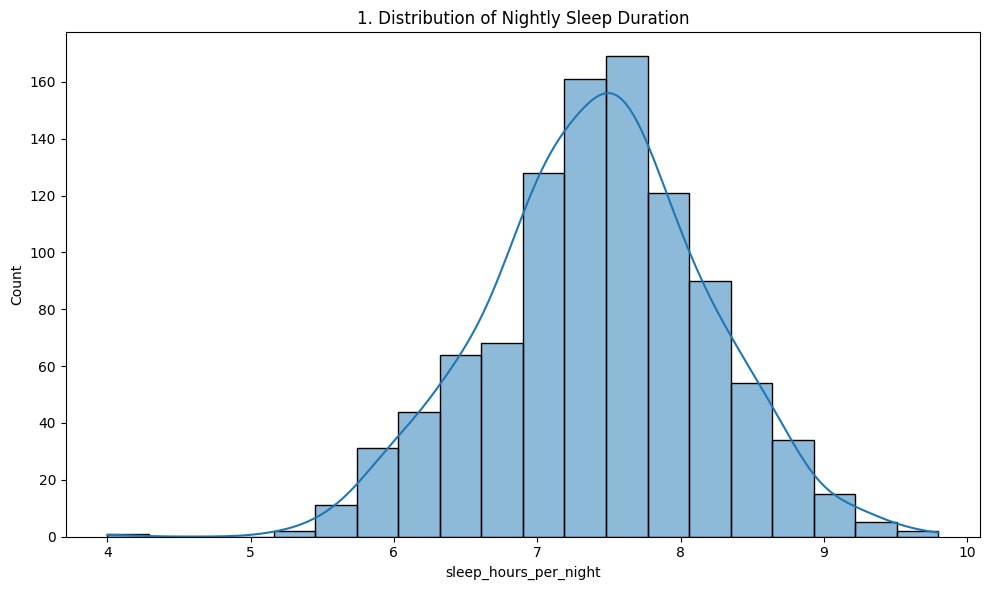

In [60]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['sleep_hours_per_night'], bins=20, kde=True)
plt.title(f'{plot_no}. Distribution of Nightly Sleep Duration')
show_fig()
plot_no += 1

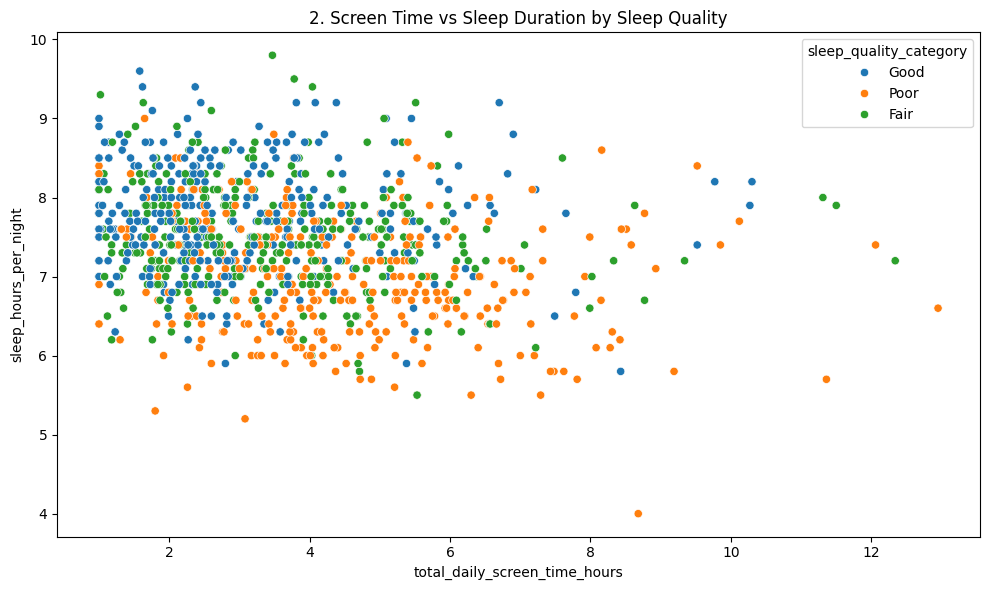

In [61]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='total_daily_screen_time_hours', y='sleep_hours_per_night', hue='sleep_quality_category')
plt.title(f'{plot_no}. Screen Time vs Sleep Duration by Sleep Quality')
show_fig()
plot_no += 1

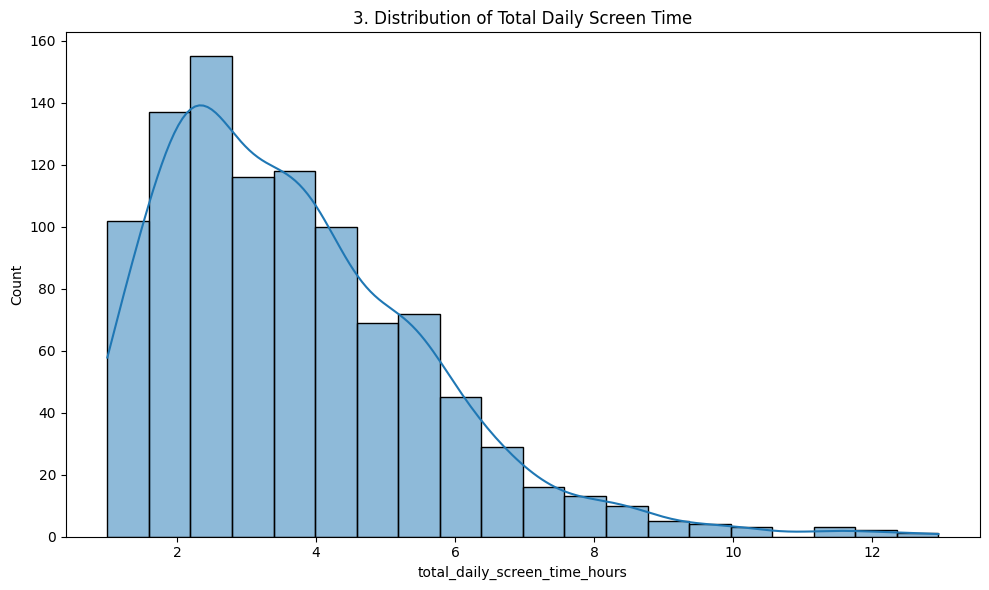

In [62]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['total_daily_screen_time_hours'], bins=20, kde=True)
plt.title(f'{plot_no}. Distribution of Total Daily Screen Time')
show_fig()
plot_no += 1

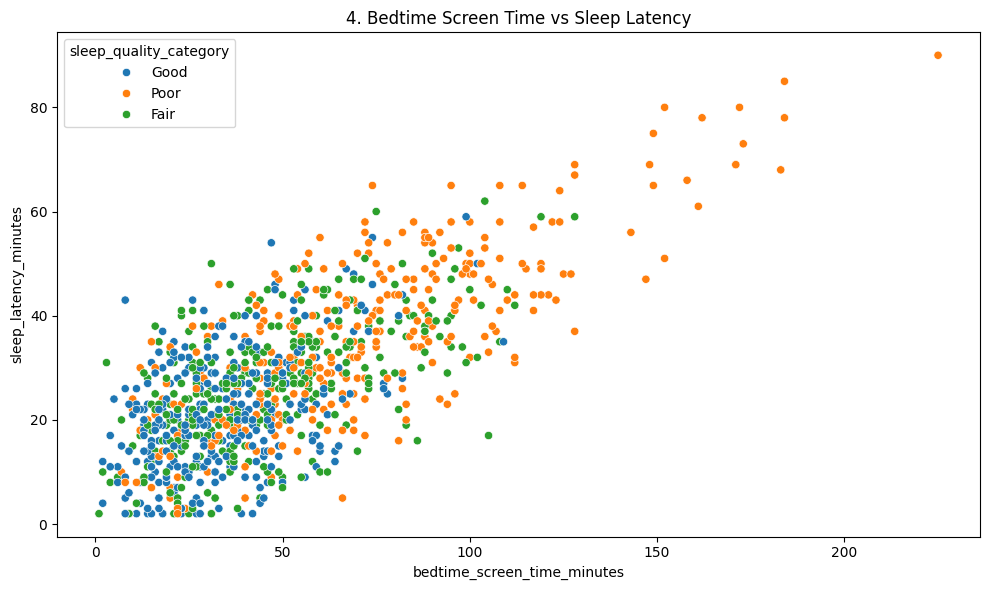

In [63]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='bedtime_screen_time_minutes', y='sleep_latency_minutes', hue='sleep_quality_category')
plt.title(f'{plot_no}. Bedtime Screen Time vs Sleep Latency')
show_fig()
plot_no += 1

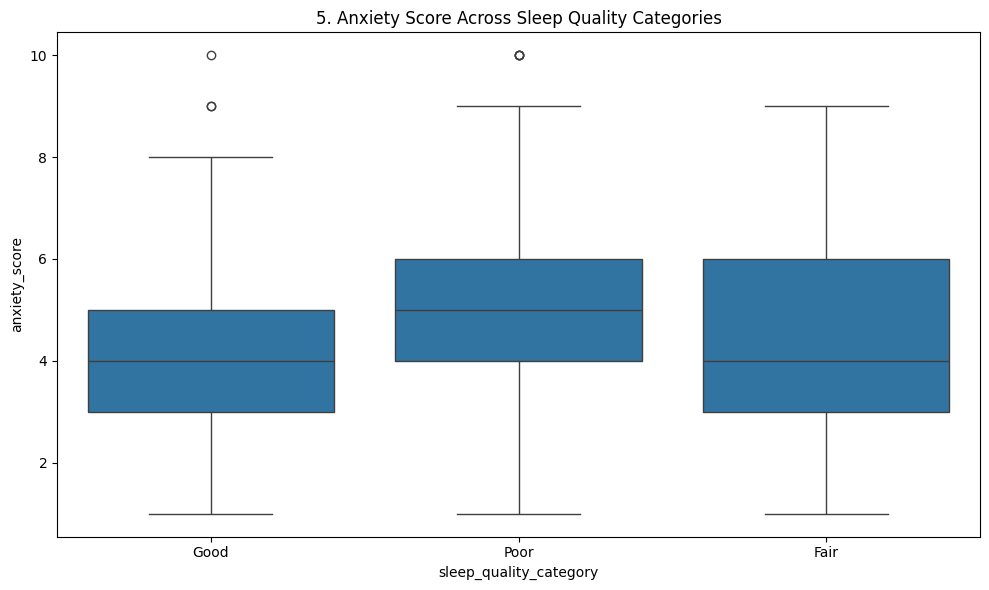

In [64]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='sleep_quality_category', y='anxiety_score')
plt.title(f'{plot_no}. Anxiety Score Across Sleep Quality Categories')
show_fig()
plot_no += 1

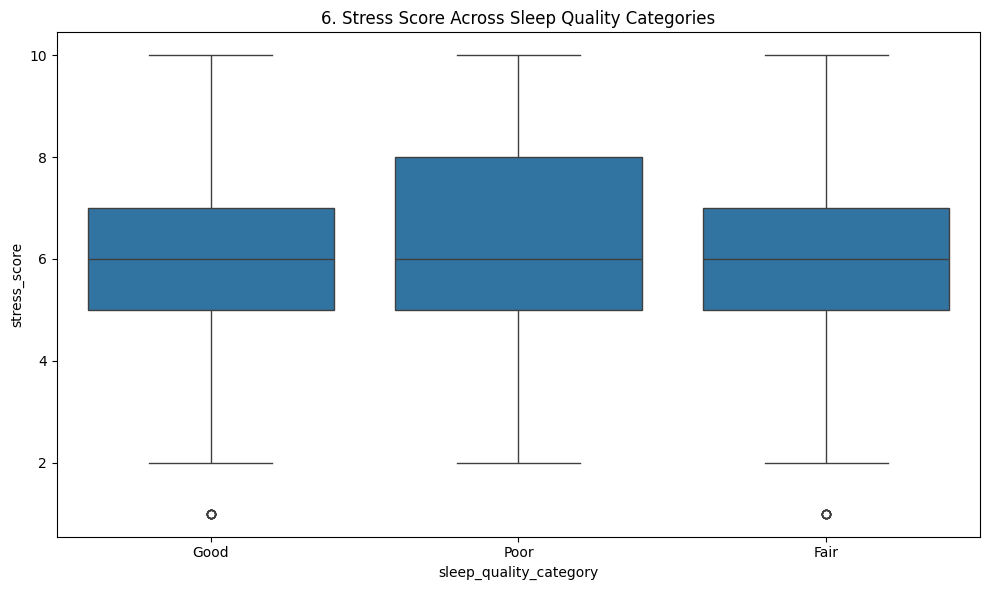

In [65]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='sleep_quality_category', y='stress_score')
plt.title(f'{plot_no}. Stress Score Across Sleep Quality Categories')
show_fig()
plot_no += 1

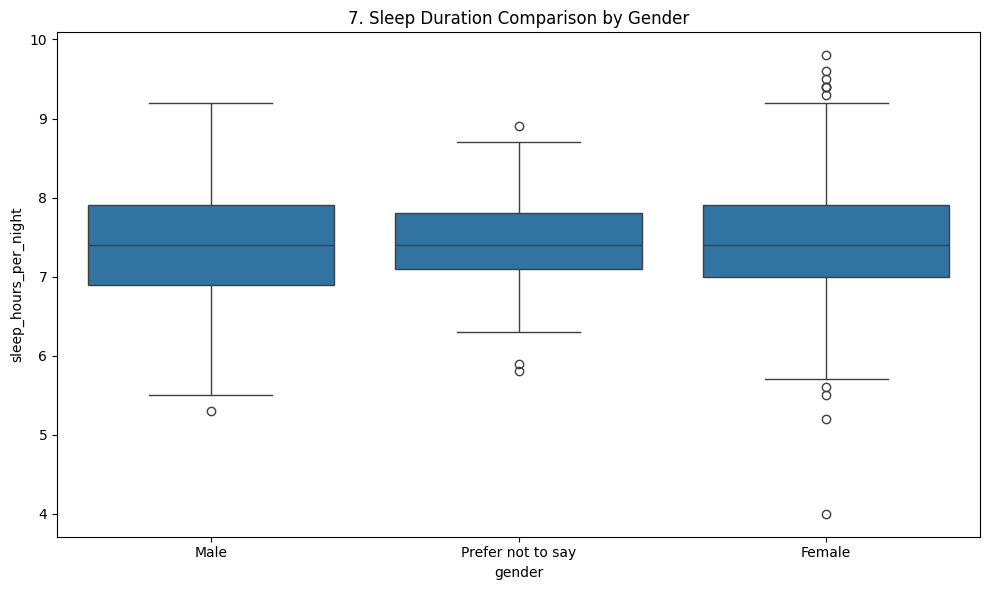

In [66]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='gender', y='sleep_hours_per_night')
plt.title(f'{plot_no}. Sleep Duration Comparison by Gender')
show_fig()
plot_no += 1

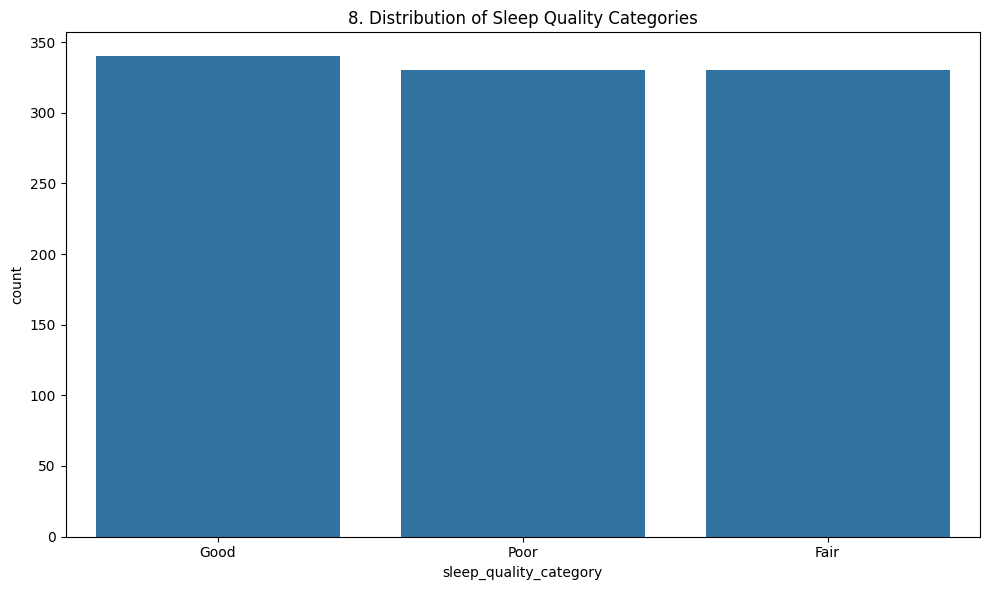

In [67]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='sleep_quality_category', order=df['sleep_quality_category'].value_counts().index)
plt.title(f'{plot_no}. Distribution of Sleep Quality Categories')
show_fig()
plot_no += 1

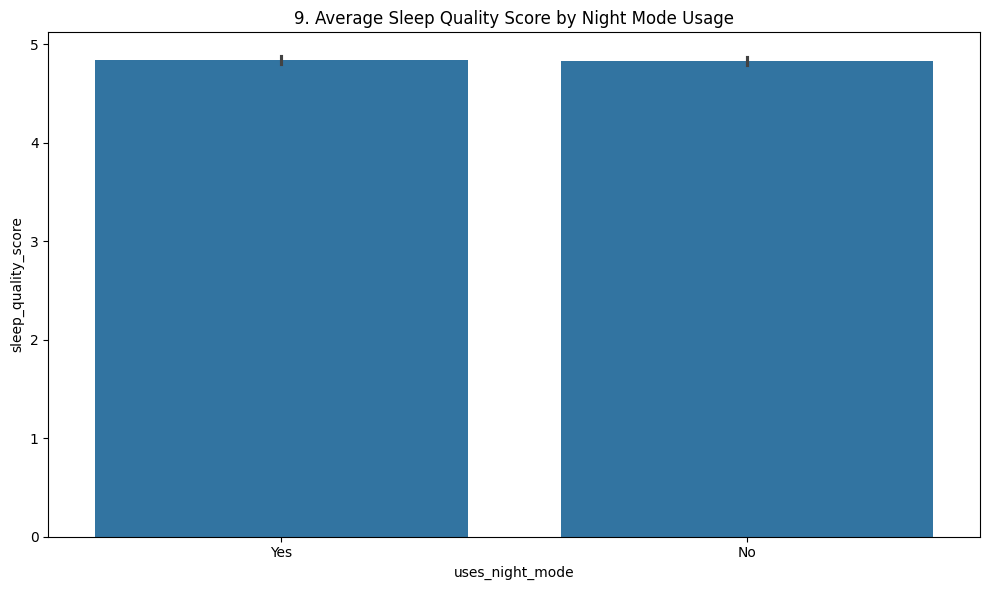

In [68]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='uses_night_mode', y='sleep_quality_score', estimator='mean')
plt.title(f'{plot_no}. Average Sleep Quality Score by Night Mode Usage')
show_fig()
plot_no += 1

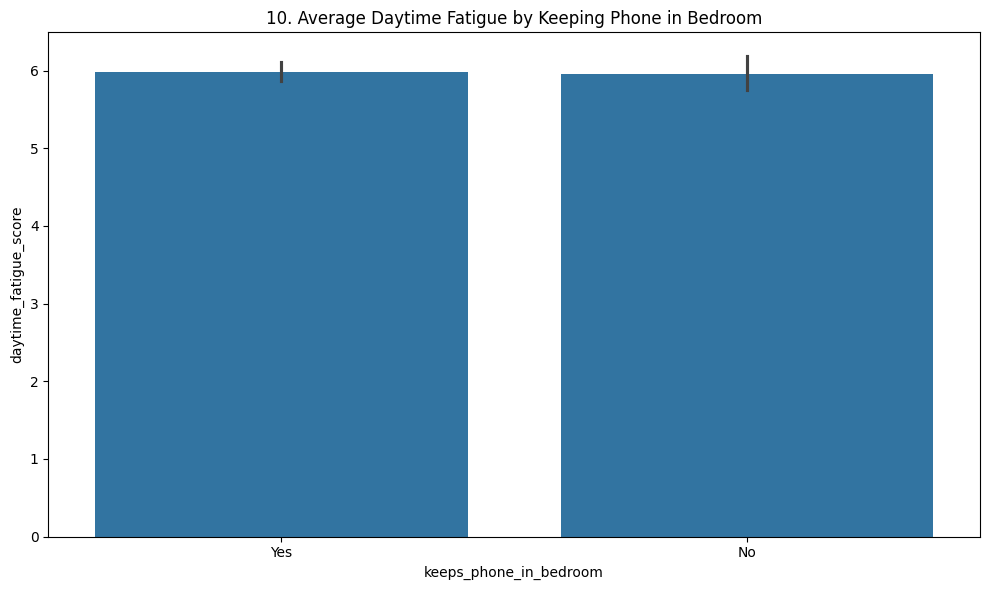

In [69]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='keeps_phone_in_bedroom', y='daytime_fatigue_score', estimator='mean')
plt.title(f'{plot_no}. Average Daytime Fatigue by Keeping Phone in Bedroom')
show_fig()
plot_no += 1

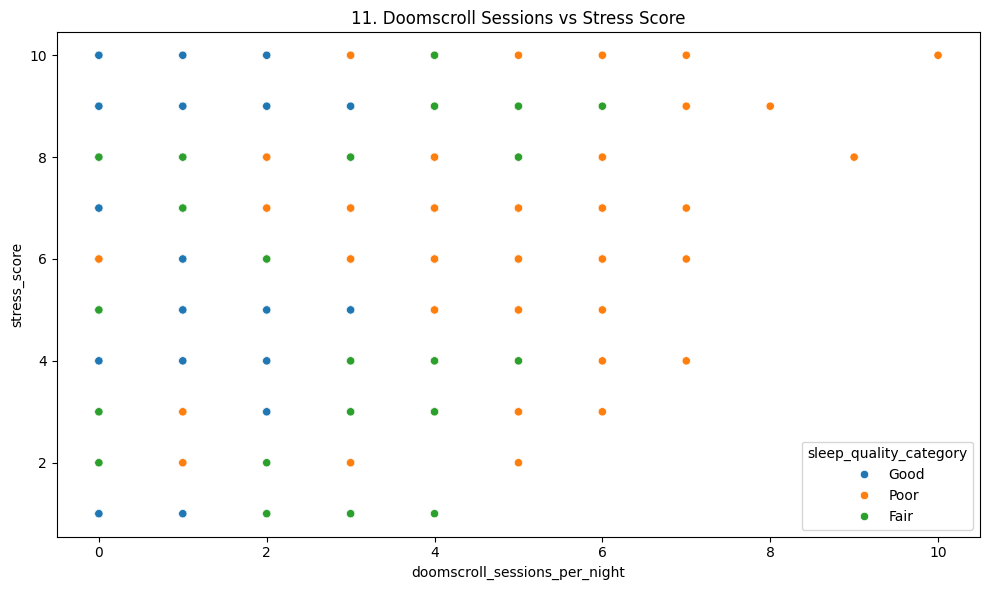

In [70]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='doomscroll_sessions_per_night', y='stress_score', hue='sleep_quality_category')
plt.title(f'{plot_no}. Doomscroll Sessions vs Stress Score')
show_fig()
plot_no += 1

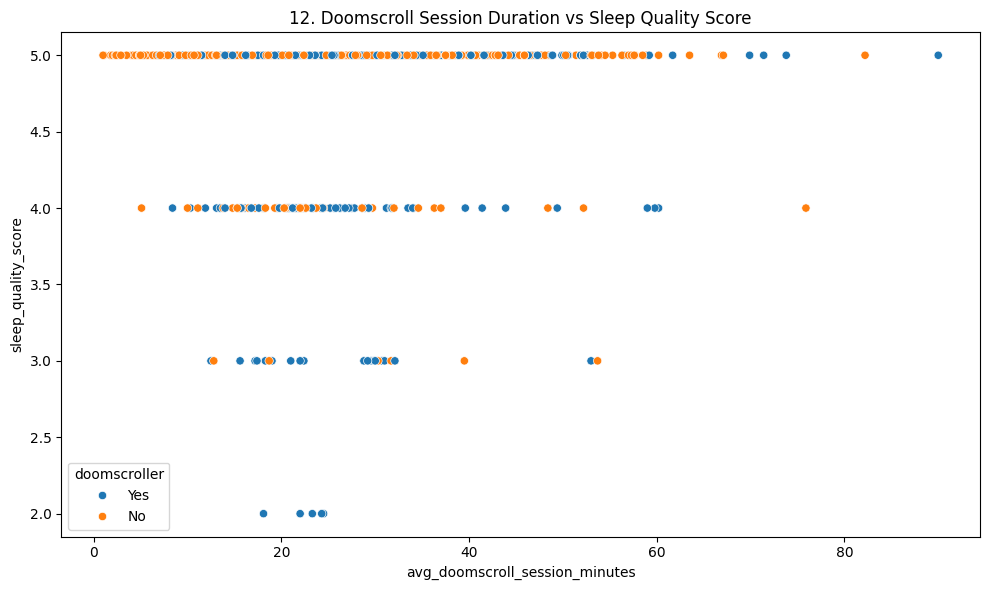

In [71]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='avg_doomscroll_session_minutes', y='sleep_quality_score', hue='doomscroller')
plt.title(f'{plot_no}. Doomscroll Session Duration vs Sleep Quality Score')
show_fig()
plot_no += 1

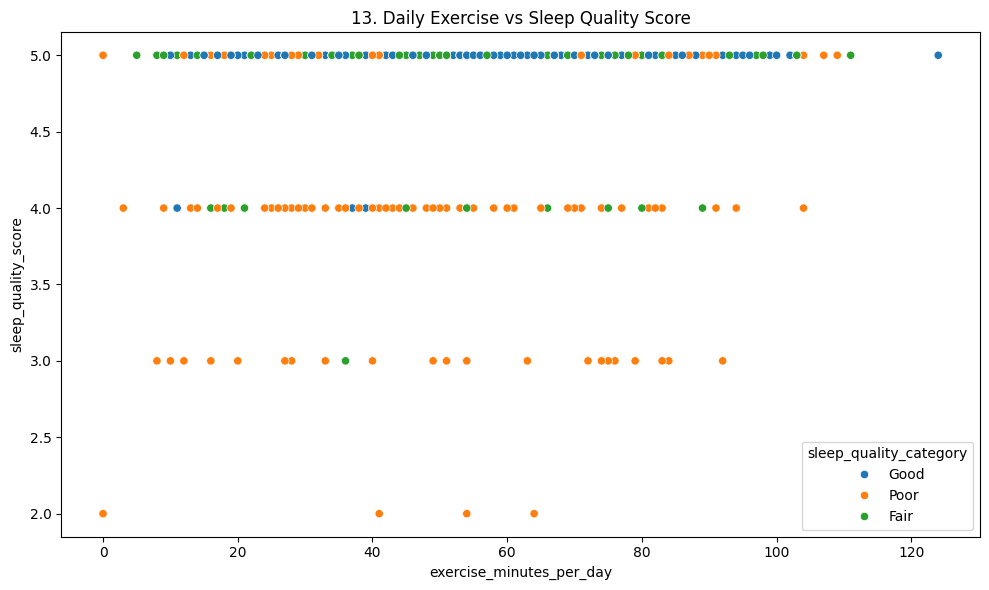

In [72]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='exercise_minutes_per_day', y='sleep_quality_score', hue='sleep_quality_category')
plt.title(f'{plot_no}. Daily Exercise vs Sleep Quality Score')
show_fig()
plot_no += 1

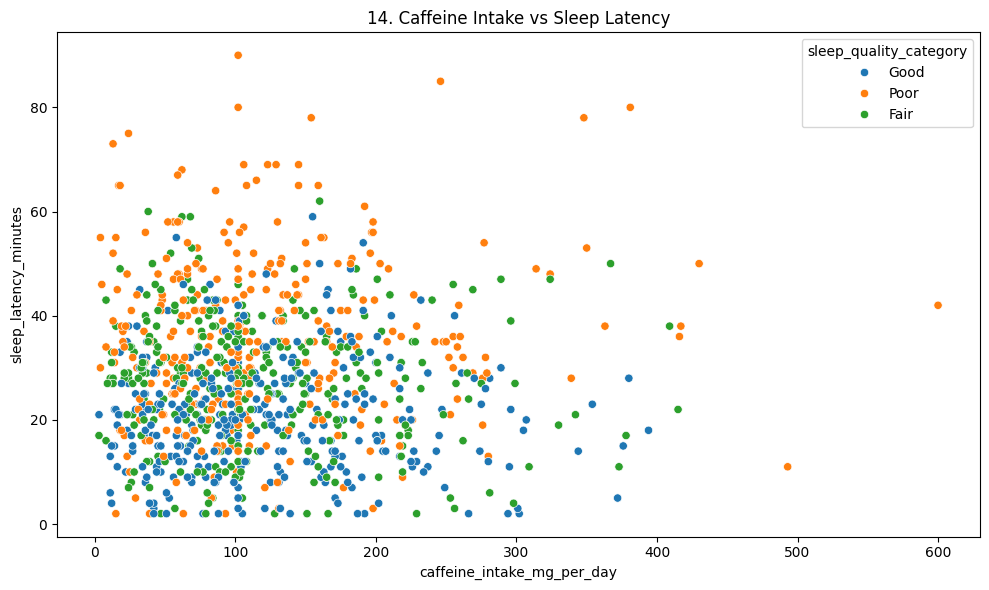

In [73]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='caffeine_intake_mg_per_day', y='sleep_latency_minutes', hue='sleep_quality_category')
plt.title(f'{plot_no}. Caffeine Intake vs Sleep Latency')
show_fig()
plot_no += 1

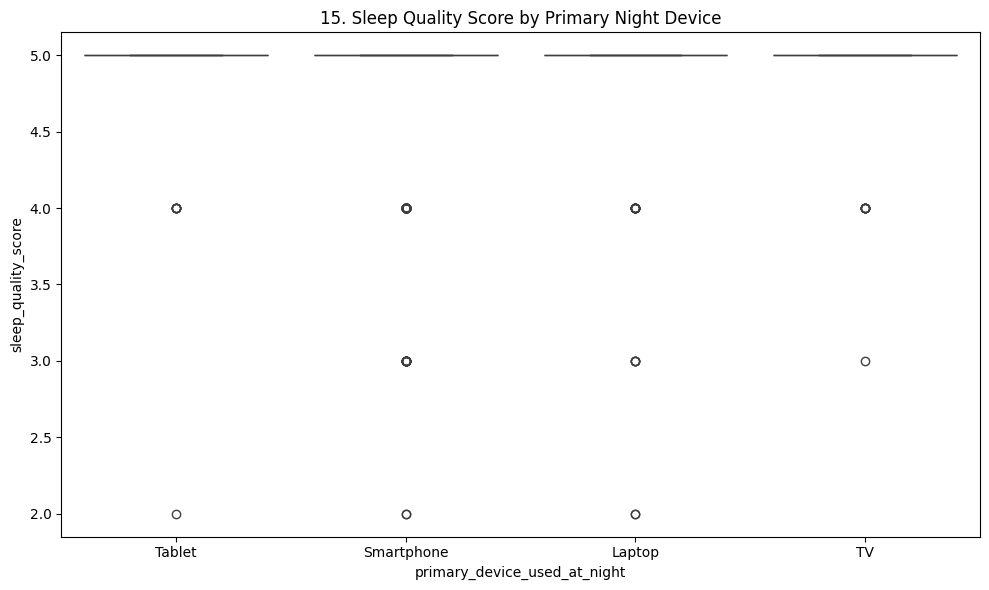

In [74]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='primary_device_used_at_night', y='sleep_quality_score')
plt.title(f'{plot_no}. Sleep Quality Score by Primary Night Device')
show_fig()
plot_no += 1

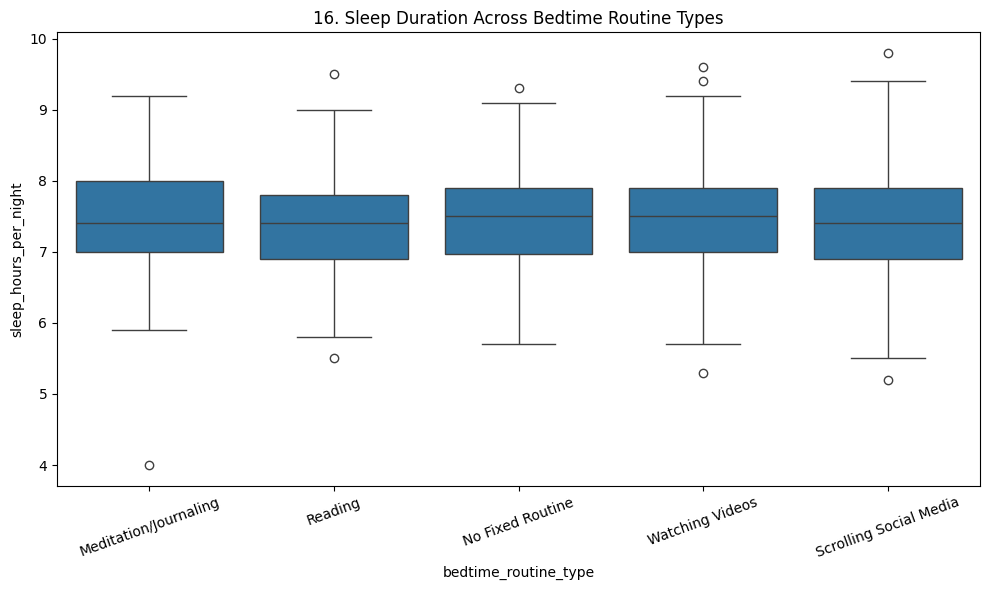

In [75]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='bedtime_routine_type', y='sleep_hours_per_night')
plt.xticks(rotation=20)
plt.title(f'{plot_no}. Sleep Duration Across Bedtime Routine Types')
show_fig()
plot_no += 1

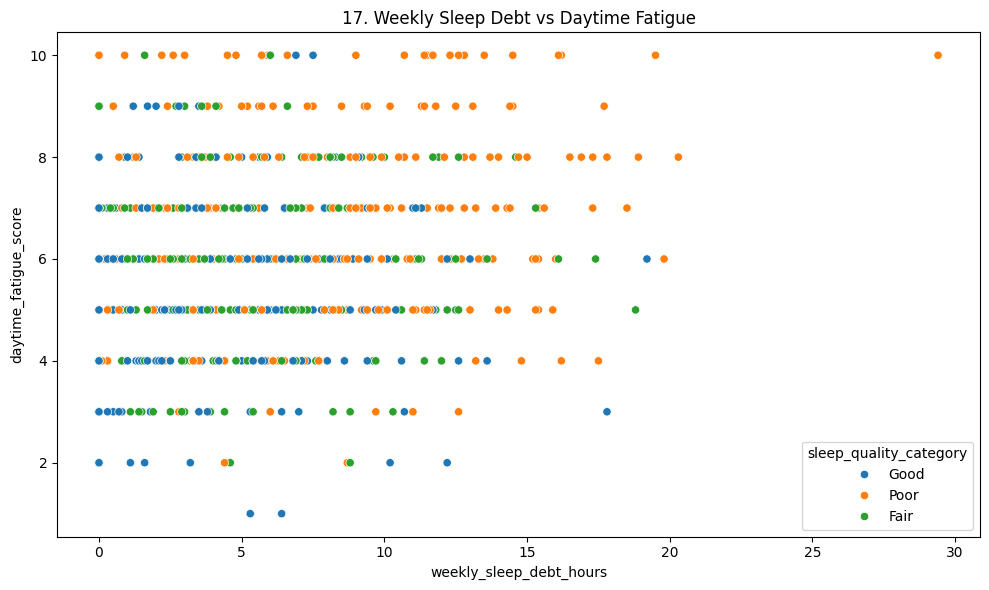

In [76]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='weekly_sleep_debt_hours', y='daytime_fatigue_score', hue='sleep_quality_category')
plt.title(f'{plot_no}. Weekly Sleep Debt vs Daytime Fatigue')
show_fig()
plot_no += 1

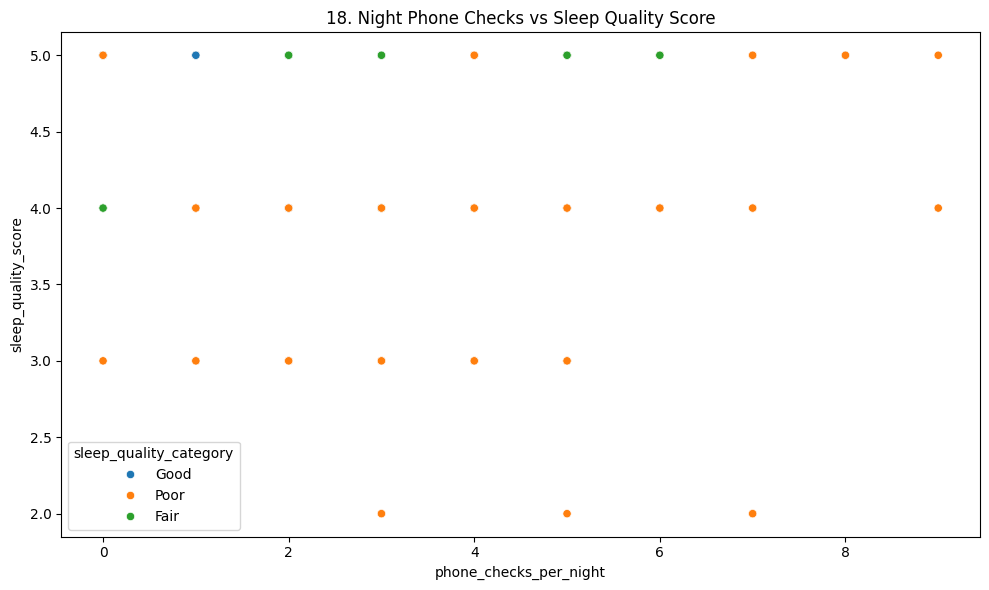

In [77]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='phone_checks_per_night', y='sleep_quality_score', hue='sleep_quality_category')
plt.title(f'{plot_no}. Night Phone Checks vs Sleep Quality Score')
show_fig()
plot_no += 1

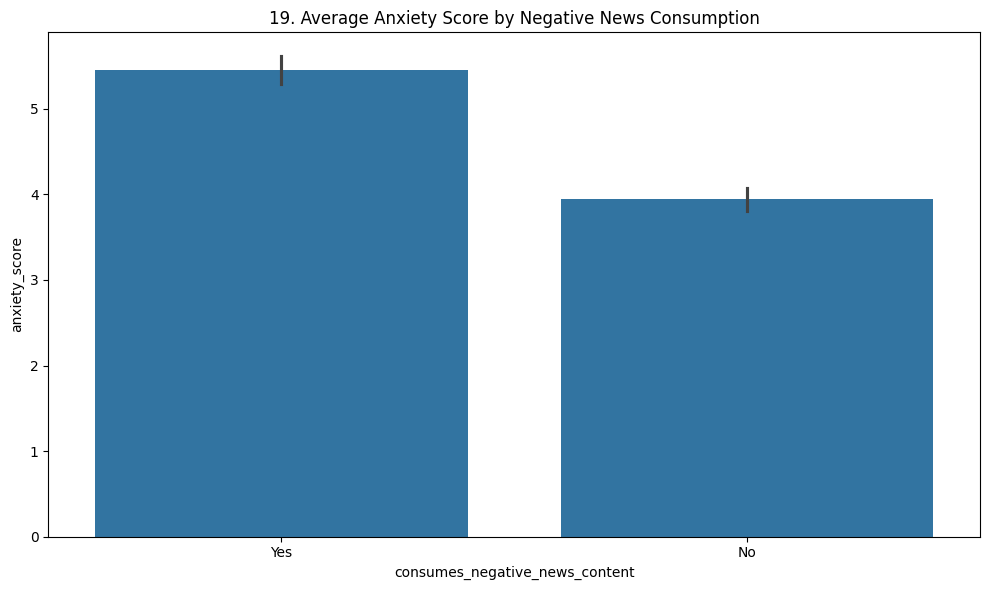

In [78]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='consumes_negative_news_content', y='anxiety_score', estimator='mean')
plt.title(f'{plot_no}. Average Anxiety Score by Negative News Consumption')
show_fig()
plot_no += 1

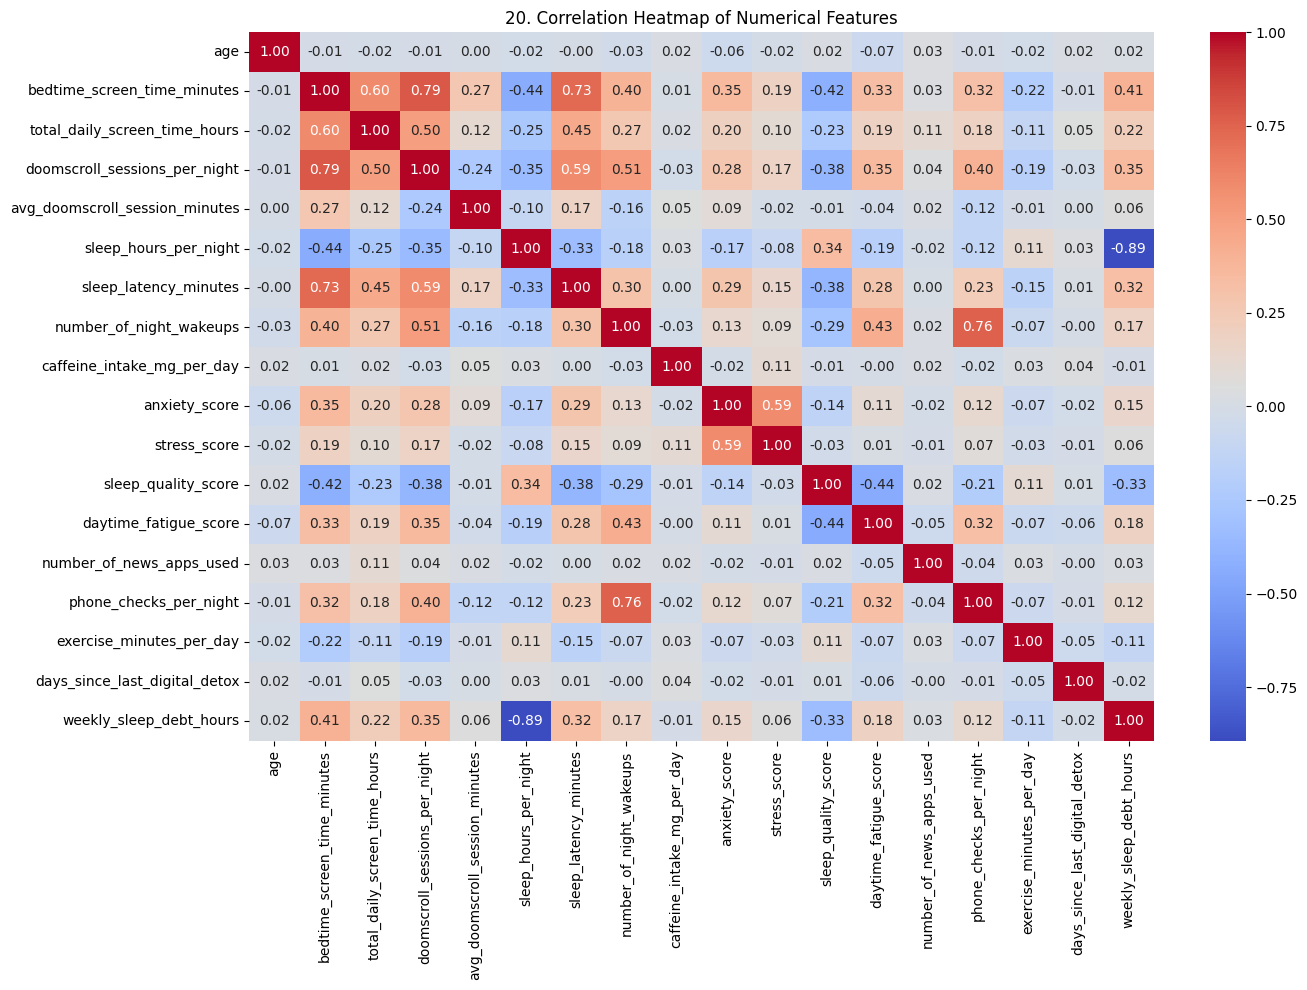

In [79]:
corr = df.select_dtypes(include='number').corr()

fig = plt.figure(figsize=(14,10))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title(f'{plot_no}. Correlation Heatmap of Numerical Features')
show_fig()
plot_no += 1

# Model Training

## Create a copy of the dataset

In [80]:
data = df.copy()

## Define target column

In [81]:
target = 'sleep_quality_category'

## Separate features and target

In [82]:
X = data.drop(columns=[target, 'respondent_id'])
y = data[target]

## Encode target labels

In [83]:
target_encoder = LabelEncoder()
y = target_encoder.fit_transform(y)

## Identify numerical and categorical columns

In [84]:
num_cols = X.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X.select_dtypes(include=['object']).columns

## Create preprocessing pipeline

In [85]:
preprocessor = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), num_cols),
    
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', __import__('sklearn').preprocessing.OneHotEncoder(handle_unknown='ignore'))
    ]), cat_cols)
])

## Split the dataset

In [86]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## Build SVM classification model

In [87]:
model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', SVC(kernel='rbf', C=1.0, gamma='scale'))
])

## Train the model

In [88]:
model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## Predict on test data

In [89]:
y_pred = model.predict(X_test)

## Print model accuracy

In [90]:
print("Accuracy Score :", round(accuracy_score(y_test, y_pred) * 100, 2), "%")

Accuracy Score : 63.0 %


## Print classification report

In [91]:
print("\nClassification Report\n")
print(classification_report(y_test, y_pred, target_names=target_encoder.classes_))


Classification Report

              precision    recall  f1-score   support

        Fair       0.52      0.48      0.50        66
        Good       0.65      0.68      0.66        68
        Poor       0.72      0.73      0.72        66

    accuracy                           0.63       200
   macro avg       0.63      0.63      0.63       200
weighted avg       0.63      0.63      0.63       200



## Plot confusion matrix

<Figure size 800x600 with 0 Axes>

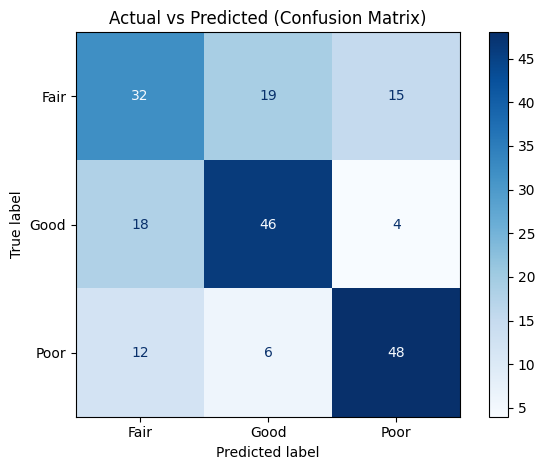

In [92]:
fig = plt.figure(figsize=(8,6))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=target_encoder.classes_,
    cmap='Blues',
    values_format='d'
)
plt.title("Actual vs Predicted (Confusion Matrix)")
plt.tight_layout()
plt.show()